# G2Gs 源码拆解与预测流程

这一份 notebook 是整套教材里最接近“读源码”的部分，但目标不是把源码一行不差地背下来，而是帮助你建立一个清晰的问题框架：

1. G2Gs 为什么要分成两个阶段？
2. 每个阶段分别在预测什么？
3. 一次完整的 retrosynthesis 推理，在代码里是怎样流动的？

如果你在阅读时觉得信息量比较大，不必着急。建议始终抓住一条主线：

**product 先被编码，再预测 center，再变成 synthons，最后一步步生成 reactants。**

---

G2Gs 的总公式可以先记成：

$$
P(R \mid P) = \sum_c P(c \mid P) \cdot P(R \mid S(c, P))
$$

其中：

- `P(c | P)`：先预测 reaction center
- `S(c, P)`：根据 center 把 product 变成 synthons
- `P(R | S)`：再从 synthon 生成 reactant


In [1]:
import os
import sys
from pathlib import Path


def find_project_root(start=None):
    here = Path(start or os.getcwd()).resolve()
    if here.is_file():
        here = here.parent
    for candidate in [here, *here.parents]:
        if (candidate / "teaching_demos").exists() and (candidate / "source_repos").exists():
            return candidate
    raise FileNotFoundError("无法定位项目根目录")


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "teaching_demos/2.single_step_retro_tutorial/2.3.semi-template/2.3.1.g2gs"
CODE_DIR = TUTORIAL_DIR / "code"
DATA_DIR = TUTORIAL_DIR / "data"

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

print(f"项目根目录: {PROJECT_ROOT}")
print(f"教程目录: {TUTORIAL_DIR}")

import torch
import pandas as pd
from IPython.display import Markdown, display
from g2gs_tutorial import (
    CenterIdentificationModel,
    SynthonCompletionModel,
    build_synthon_completion_dataset,
    draw_reaction_pair_image,
    identify_reaction_center,
    load_demo_reactions,
    molecule_to_graph_tensor,
)

torch.manual_seed(7)


def show_source_block(relative_path, start, end, title):
    path = PROJECT_ROOT / relative_path
    lines = path.read_text(encoding="utf-8").splitlines()
    snippet = "\n".join(f"{line_no:4d} | {lines[line_no - 1]}" for line_no in range(start, end + 1))
    display(Markdown(f"### {title}\n`{relative_path}:{start}-{end}`"))
    display(Markdown(f"```python\n{snippet}\n```"))


SOURCE_BLOCKS = [
    {
        "stage": "图编码器",
        "source_file": "source_repos/torchdrug/torchdrug/models/gcn.py",
        "symbol": "RelationalGraphConvolutionalNetwork",
        "lines": "88-168",
    },
    {
        "stage": "数据预处理",
        "source_file": "source_repos/torchdrug/torchdrug/datasets/uspto50k.py",
        "symbol": "_get_difference / _get_reaction_center / _get_synthon",
        "lines": "97-220",
    },
    {
        "stage": "中心打分",
        "source_file": "source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py",
        "symbol": "CenterIdentification.predict",
        "lines": "118-154",
    },
    {
        "stage": "中心转 synthon",
        "source_file": "source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py",
        "symbol": "CenterIdentification.predict_synthon",
        "lines": "168-233",
    },
    {
        "stage": "单步动作打分",
        "source_file": "source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py",
        "symbol": "SynthonCompletion._topk_action",
        "lines": "701-788",
    },
    {
        "stage": "beam search 展开",
        "source_file": "source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py",
        "symbol": "SynthonCompletion._apply_action / predict_reactant",
        "lines": "790-920",
    },
    {
        "stage": "总装预测",
        "source_file": "source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py",
        "symbol": "Retrosynthesis.predict",
        "lines": "1090-1158",
    },
]


项目根目录: /home/xiaoruiwang/backup_data/ubuntu_data/other_work/GNN_AIDD/Chemical_Synthesis
教程目录: /home/xiaoruiwang/backup_data/ubuntu_data/other_work/GNN_AIDD/Chemical_Synthesis/teaching_demos/2.single_step_retro_tutorial/2.3.semi-template/2.3.1.g2gs


## 1. 先看源码地图

对于第一次读源码的同学，最容易遇到的问题不是“看不懂某一行”，而是“不知道应该先看哪几段”。

所以这里先给出一张阅读地图，把 G2Gs 的核心源码块按预测流程排好。后面我们就按照这个顺序逐段拆解。


In [2]:
display(pd.DataFrame(SOURCE_BLOCKS))

,stage,source_file,symbol,lines
0,图编码器,source_repos/torchdrug/torchdrug/models/gcn.py,RelationalGraphConvolutionalNetwork,88-168
1,数据预处理,source_repos/torchdrug/torchdrug/datasets/uspt...,_get_difference / _get_reaction_center / _get_...,97-220
2,中心打分,source_repos/torchdrug/torchdrug/tasks/retrosy...,CenterIdentification.predict,118-154
3,中心转 synthon,source_repos/torchdrug/torchdrug/tasks/retrosy...,CenterIdentification.predict_synthon,168-233
4,单步动作打分,source_repos/torchdrug/torchdrug/tasks/retrosy...,SynthonCompletion._topk_action,701-788
5,beam search 展开,source_repos/torchdrug/torchdrug/tasks/retrosy...,SynthonCompletion._apply_action / predict_reac...,790-920
6,总装预测,source_repos/torchdrug/torchdrug/tasks/retrosy...,Retrosynthesis.predict,1090-1158


## 2. RGCN：公共图编码骨干

无论是第一阶段的中心预测，还是第二阶段的 synthon completion，都先要把分子图编码成向量表示。

在 `torchdrug` 里，这个公共骨干就是 `models.RGCN`。

阅读这一部分时，你不需要纠结每一层卷积的实现细节，先抓住最重要的结论：

- 输入是分子图和节点特征
- 输出是 `node_feature` 和 `graph_feature`
- 后面的任务头都建立在这两个张量之上


In [3]:
show_source_block(
    "source_repos/torchdrug/torchdrug/models/gcn.py",
    88,
    168,
    "RGCN: `RelationalGraphConvolutionalNetwork`",
)


### RGCN: `RelationalGraphConvolutionalNetwork`
`source_repos/torchdrug/torchdrug/models/gcn.py:88-168`

```python
  88 | @R.register("models.RGCN")
  89 | class RelationalGraphConvolutionalNetwork(nn.Module, core.Configurable):
  90 |     """
  91 |     Relational Graph Convolutional Network proposed in `Modeling Relational Data with Graph Convolutional Networks?`_.
  92 | 
  93 |     .. _Modeling Relational Data with Graph Convolutional Networks?:
  94 |         https://arxiv.org/pdf/1703.06103.pdf
  95 | 
  96 |     Parameters:
  97 |         input_dim (int): input dimension
  98 |         hidden_dims (list of int): hidden dimensions
  99 |         num_relation (int): number of relations
 100 |         edge_input_dim (int, optional): dimension of edge features
 101 |         short_cut (bool, optional): use short cut or not
 102 |         batch_norm (bool, optional): apply batch normalization or not
 103 |         activation (str or function, optional): activation function
 104 |         concat_hidden (bool, optional): concat hidden representations from all layers as output
 105 |         readout (str, optional): readout function. Available functions are ``sum`` and ``mean``.
 106 |     """
 107 | 
 108 |     def __init__(self, input_dim, hidden_dims, num_relation, edge_input_dim=None, short_cut=False, batch_norm=False,
 109 |                  activation="relu", concat_hidden=False, readout="sum"):
 110 |         super(RelationalGraphConvolutionalNetwork, self).__init__()
 111 | 
 112 |         if not isinstance(hidden_dims, Sequence):
 113 |             hidden_dims = [hidden_dims]
 114 |         self.input_dim = input_dim
 115 |         self.output_dim = hidden_dims[-1] * (len(hidden_dims) if concat_hidden else 1)
 116 |         self.dims = [input_dim] + list(hidden_dims)
 117 |         self.num_relation = num_relation
 118 |         self.short_cut = short_cut
 119 |         self.concat_hidden = concat_hidden
 120 | 
 121 |         self.layers = nn.ModuleList()
 122 |         for i in range(len(self.dims) - 1):
 123 |             self.layers.append(layers.RelationalGraphConv(self.dims[i], self.dims[i + 1], num_relation, edge_input_dim,
 124 |                                                           batch_norm, activation))
 125 | 
 126 |         if readout == "sum":
 127 |             self.readout = layers.SumReadout()
 128 |         elif readout == "mean":
 129 |             self.readout = layers.MeanReadout()
 130 |         else:
 131 |             raise ValueError("Unknown readout `%s`" % readout)
 132 | 
 133 |     def forward(self, graph, input, all_loss=None, metric=None):
 134 |         """
 135 |         Compute the node representations and the graph representation(s).
 136 | 
 137 |         Require the graph(s) to have the same number of relations as this module.
 138 | 
 139 |         Parameters:
 140 |             graph (Graph): :math:`n` graph(s)
 141 |             input (Tensor): input node representations
 142 |             all_loss (Tensor, optional): if specified, add loss to this tensor
 143 |             metric (dict, optional): if specified, output metrics to this dict
 144 | 
 145 |         Returns:
 146 |             dict with ``node_feature`` and ``graph_feature`` fields:
 147 |                 node representations of shape :math:`(|V|, d)`, graph representations of shape :math:`(n, d)`
 148 |         """
 149 |         hiddens = []
 150 |         layer_input = input
 151 | 
 152 |         for layer in self.layers:
 153 |             hidden = layer(graph, layer_input)
 154 |             if self.short_cut and hidden.shape == layer_input.shape:
 155 |                 hidden = hidden + layer_input
 156 |             hiddens.append(hidden)
 157 |             layer_input = hidden
 158 | 
 159 |         if self.concat_hidden:
 160 |             node_feature = torch.cat(hiddens, dim=-1)
 161 |         else:
 162 |             node_feature = hiddens[-1]
 163 |         graph_feature = self.readout(graph, node_feature)
 164 | 
 165 |         return {
 166 |             "graph_feature": graph_feature,
 167 |             "node_feature": node_feature
 168 |         }
```

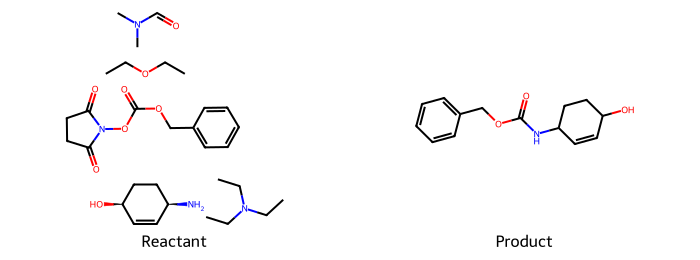

,tensor,shape
0,product_graph.node_feature,"(18, 43)"
1,encoder_output['node_feature'],"(18, 192)"
2,encoder_output['graph_feature'],"(1, 192)"


In [4]:
examples = load_demo_reactions()
example = next(item for item in examples if item.reaction_id == "demo_01")
center = identify_reaction_center(example.reactant_mol, example.product_mol)
product_graph = molecule_to_graph_tensor(example.product_mol, atom_feature_mode="center_identification")

display(draw_reaction_pair_image(example.reactant_mol, example.product_mol, ["Reactant", "Product"]))

center_model = CenterIdentificationModel(
    node_input_dim=product_graph.node_feature.shape[-1],
    edge_input_dim=product_graph.edge_feature.shape[-1],
    num_relation=4,
    num_reaction=10,
    hidden_dim=64,
    num_layers=3,
)
encoder_output = center_model.encoder(product_graph, product_graph.node_feature.float())

display(
    pd.DataFrame(
        [
            {"tensor": "product_graph.node_feature", "shape": tuple(product_graph.node_feature.shape)},
            {"tensor": "encoder_output['node_feature']", "shape": tuple(encoder_output["node_feature"].shape)},
            {"tensor": "encoder_output['graph_feature']", "shape": tuple(encoder_output["graph_feature"].shape)},
        ]
    )
)


从源码和张量形状都能看出一个关键事实：**RGCN 只负责把分子图编码好，并不直接负责输出 reactants。**

把这一点想清楚之后，后面的两阶段结构就会容易很多：

- 编码器负责提供表示
- 任务头负责把表示变成具体预测


## 3. 数据预处理：center 与 synthon 的定义来自哪里

在学习模型之前，先回到数据定义本身。

因为模型到底在“学什么”，其实首先由数据处理代码决定。这里的 `USPTO50k` 源码规定了：

1. reactant 和 product 如何比较差异
2. reaction center 如何被标注出来
3. product 如何被拆成 synthons

如果这一步没有理解透，后面读模型代码时就会很容易迷糊。


In [5]:
show_source_block(
    "source_repos/torchdrug/torchdrug/datasets/uspto50k.py",
    97,
    220,
    "USPTO50k: `_get_difference`, `_get_reaction_center`, `_get_synthon`",
)


### USPTO50k: `_get_difference`, `_get_reaction_center`, `_get_synthon`
`source_repos/torchdrug/torchdrug/datasets/uspto50k.py:97-220`

```python
  97 |     def _get_difference(self, reactant, product):
  98 |         product2id = product.atom_map
  99 |         id2reactant = torch.zeros(product2id.max() + 1, dtype=torch.long)
 100 |         id2reactant[reactant.atom_map] = torch.arange(reactant.num_node)
 101 |         prod2react = id2reactant[product2id]
 102 | 
 103 |         # check edges in the product
 104 |         product = product.directed()
 105 |         # O(n^2) brute-force match is faster than O(nlogn) data.Graph.match for small molecules
 106 |         mapped_edge = product.edge_list.clone()
 107 |         mapped_edge[:, :2] = prod2react[mapped_edge[:, :2]]
 108 |         is_same_index = mapped_edge.unsqueeze(0) == reactant.edge_list.unsqueeze(1)
 109 |         has_typed_edge = is_same_index.all(dim=-1).any(dim=0)
 110 |         has_edge = is_same_index[:, :, :2].all(dim=-1).any(dim=0)
 111 |         is_added = ~has_edge
 112 |         is_modified = has_edge & ~has_typed_edge
 113 |         edge_added = product.edge_list[is_added, :2]
 114 |         edge_modified = product.edge_list[is_modified, :2]
 115 | 
 116 |         return edge_added, edge_modified, prod2react
 117 | 
 118 |     def _get_reaction_center(self, reactant, product):
 119 |         edge_added, edge_modified, prod2react = self._get_difference(reactant, product)
 120 | 
 121 |         edge_label = torch.zeros(product.num_edge, dtype=torch.long)
 122 |         node_label = torch.zeros(product.num_node, dtype=torch.long)
 123 | 
 124 |         if len(edge_added) > 0:
 125 |             if len(edge_added) == 1: # add a single edge
 126 |                 any = -torch.ones(1, 1, dtype=torch.long)
 127 |                 pattern = torch.cat([edge_added, any], dim=-1)
 128 |                 index, num_match = product.match(pattern)
 129 |                 assert num_match.item() == 1
 130 |                 edge_label[index] = 1
 131 |                 h, t = edge_added[0]
 132 |                 reaction_center = torch.tensor([product.atom_map[h], product.atom_map[t]])
 133 |         else:
 134 |             if len(edge_modified) == 1: # modify a single edge
 135 |                 h, t = edge_modified[0]
 136 |                 if product.degree_in[h] == 1:
 137 |                     node_label[h] = 1
 138 |                     reaction_center = torch.tensor([product.atom_map[h], 0])
 139 |                 elif product.degree_in[t] == 1:
 140 |                     node_label[t] = 1
 141 |                     reaction_center = torch.tensor([product.atom_map[t], 0])
 142 |                 else:
 143 |                     # pretend the reaction center is h
 144 |                     node_label[h] = 1
 145 |                     reaction_center = torch.tensor([product.atom_map[h], 0])
 146 |             else:
 147 |                 product_hs = torch.tensor([atom.GetTotalNumHs() for atom in product.to_molecule().GetAtoms()])
 148 |                 reactant_hs = torch.tensor([atom.GetTotalNumHs() for atom in reactant.to_molecule().GetAtoms()])
 149 |                 atom_modified = (product_hs != reactant_hs[prod2react]).nonzero().flatten()
 150 |                 if len(atom_modified) == 1: # modify single node
 151 |                     node_label[atom_modified] = 1
 152 |                     reaction_center = torch.tensor([product.atom_map[atom_modified[0]], 0])
 153 | 
 154 |         if edge_label.sum() + node_label.sum() == 0:
 155 |             return [], []
 156 | 
 157 |         with product.edge():
 158 |             product.edge_label = edge_label
 159 |         with product.node():
 160 |             product.node_label = node_label
 161 |         with reactant.graph():
 162 |             reactant.reaction_center = reaction_center
 163 |         with product.graph():
 164 |             product.reaction_center = reaction_center
 165 |         return [reactant], [product]
 166 | 
 167 |     def _get_synthon(self, reactant, product):
 168 |         edge_added, edge_modified, prod2react = self._get_difference(reactant, product)
 169 | 
 170 |         reactants = []
 171 |         synthons = []
 172 | 
 173 |         if len(edge_added) > 0:
 174 |             if len(edge_added) == 1:  # add a single edge
 175 |                 reverse_edge = edge_added.flip(1)
 176 |                 any = -torch.ones(2, 1, dtype=torch.long)
 177 |                 pattern = torch.cat([edge_added, reverse_edge])
 178 |                 pattern = torch.cat([pattern, any], dim=-1)
 179 |                 index, num_match = product.match(pattern)
 180 |                 edge_mask = torch.ones(product.num_edge, dtype=torch.bool)
 181 |                 edge_mask[index] = 0
 182 |                 product = product.edge_mask(edge_mask)
 183 |                 _reactants = reactant.connected_components()[0]
 184 |                 _synthons = product.connected_components()[0]
 185 |                 assert len(_synthons) >= len(_reactants) # because a few samples contain multiple products
 186 | 
 187 |                 h, t = edge_added[0]
 188 |                 reaction_center = torch.tensor([product.atom_map[h], product.atom_map[t]])
 189 |                 with _reactants.graph():
 190 |                     _reactants.reaction_center = reaction_center.expand(len(_reactants), -1)
 191 |                 with _synthons.graph():
 192 |                     _synthons.reaction_center = reaction_center.expand(len(_synthons), -1)
 193 |                 # reactant / sython can be uniquely indexed by their maximal atom mapping ID
 194 |                 reactant_id = scatter_max(_reactants.atom_map, _reactants.node2graph, dim_size=len(_reactants))[0]
 195 |                 synthon_id = scatter_max(_synthons.atom_map, _synthons.node2graph, dim_size=len(_synthons))[0]
 196 |                 react2synthon = (reactant_id.unsqueeze(-1) == synthon_id.unsqueeze(0)).long().argmax(-1)
 197 |                 react2synthon = react2synthon.tolist()
 198 |                 for r, s in enumerate(react2synthon):
 199 |                     reactants.append(_reactants[r])
 200 |                     synthons.append(_synthons[s])
 201 |         else:
 202 |             num_cc = reactant.connected_components()[1]
 203 |             assert num_cc == 1
 204 | 
 205 |             if len(edge_modified) == 1:  # modify a single edge
 206 |                 synthon = product
 207 |                 h, t = edge_modified[0]
 208 |                 if product.degree_in[h] == 1:
 209 |                     reaction_center = torch.tensor([product.atom_map[h], 0])
 210 |                 elif product.degree_in[t] == 1:
 211 |                     reaction_center = torch.tensor([product.atom_map[t], 0])
 212 |                 else:
 213 |                     # pretend the reaction center is h
 214 |                     reaction_center = torch.tensor([product.atom_map[h], 0])
 215 |                 with reactant.graph():
 216 |                     reactant.reaction_center = reaction_center
 217 |                 with synthon.graph():
 218 |                     synthon.reaction_center = reaction_center
 219 |                 reactants.append(reactant)
 220 |                 synthons.append(synthon)
```

In [6]:
synthon_dataset = build_synthon_completion_dataset([example])
display(
    pd.DataFrame(
        [
            {
                "pair_id": sample["pair_id"],
                "reaction_center": sample["reaction_center"],
                "reactant_smiles": sample["reactant_smiles"],
                "synthon_smiles": sample["synthon_smiles"],
            }
            for sample in synthon_dataset
        ]
    )
)


,pair_id,reaction_center,reactant_smiles,synthon_smiles
0,demo_01_pair_0,"(2, 3)",O=C1CCC(=O)N1O[C:2](=[O:1])[O:11][CH2:12][c:13...,[O:1]=[C:2][O:11][CH2:12][c:13]1[cH:14][cH:15]...
1,demo_01_pair_1,"(2, 3)",[NH2:3][C@H:4]1[CH:5]=[CH:6][C@@H:7]([OH:8])[C...,[NH:3][CH:4]1[CH:5]=[CH:6][CH:7]([OH:8])[CH2:9...


这一步也是理解“两阶段设计”最自然的入口：

- 第一阶段不是直接预测 reactants，而是先预测 center
- 第二阶段也不是直接接收完整 product，而是接收由 center 生成的 synthons

换句话说，**中间表示不是附属品，而是 G2Gs 设计的核心。**


## 4. 第一阶段：CenterIdentification 源码

现在开始进入真正的预测部分。

读 `CenterIdentification` 时，建议你重点关注三个问题：

1. 输入除了 encoder 输出，还拼接了哪些条件信息？
2. 为什么要同时给节点和边打分？
3. top-k 的 center 候选是怎样转成 synthons 的？

只要把这三个问题读清楚，第一阶段的整体逻辑就已经掌握了。


In [7]:
show_source_block(
    "source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py",
    118,
    154,
    "CenterIdentification: `predict()`",
)


### CenterIdentification: `predict()`
`source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py:118-154`

```python
 118 |     def predict(self, batch, all_loss=None, metric=None):
 119 |         reactant, product = batch["graph"]
 120 |         output = self.model(product, product.node_feature.float(), all_loss, metric)
 121 | 
 122 |         graph = product.directed()
 123 | 
 124 |         node_feature = [output["node_feature"]]
 125 |         edge_feature = []
 126 |         graph_feature = []
 127 |         for _feature in sorted(self.feature):
 128 |             if _feature == "reaction":
 129 |                 reaction_feature = torch.zeros(len(graph), self.num_reaction, dtype=torch.float32, device=self.device)
 130 |                 reaction_feature.scatter_(1, batch["reaction"].unsqueeze(-1), 1)
 131 |                 graph_feature.append(reaction_feature)
 132 |             elif _feature == "graph":
 133 |                 graph_feature.append(output["graph_feature"])
 134 |             elif _feature == "atom":
 135 |                 node_feature.append(graph.node_feature.float())
 136 |             elif _feature == "bond":
 137 |                 edge_feature.append(graph.edge_feature.float())
 138 |             else:
 139 |                 raise ValueError("Unknown feature `%s`" % _feature)
 140 | 
 141 |         graph_feature = torch.cat(graph_feature, dim=-1)
 142 |         # inherit graph features
 143 |         node_feature.append(graph_feature[graph.node2graph])
 144 |         node_feature = torch.cat(node_feature, dim=-1)
 145 |         # inherit node features
 146 |         edge_feature.append(node_feature[graph.edge_list[:, :2]].flatten(1))
 147 |         edge_feature = torch.cat(edge_feature, dim=-1)
 148 |         
 149 |         edge_pred = self.edge_mlp(edge_feature).squeeze(-1)
 150 |         node_pred = self.node_mlp(node_feature).squeeze(-1)
 151 | 
 152 |         pred = self._collate(edge_pred, node_pred, graph)
 153 | 
 154 |         return pred
```

In [8]:
show_source_block(
    "source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py",
    168,
    233,
    "CenterIdentification: `predict_synthon()`",
)


### CenterIdentification: `predict_synthon()`
`source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py:168-233`

```python
 168 |     @torch.no_grad()
 169 |     def predict_synthon(self, batch, k=1):
 170 |         """
 171 |         Predict top-k synthons from target molecules.
 172 | 
 173 |         Parameters:
 174 |             batch (dict): batch of target molecules
 175 |             k (int, optional): return top-k results
 176 | 
 177 |         Returns:
 178 |             list of dict: top k records.
 179 |                 Each record is a batch dict of keys ``synthon``, ``num_synthon``, ``reaction_center``,
 180 |                 ``log_likelihood`` and ``reaction``.
 181 |         """
 182 |         pred = self.predict(batch)
 183 |         target, size = self.target(batch)
 184 |         logp = functional.variadic_log_softmax(pred, size)
 185 | 
 186 |         reactant, product = batch["graph"]
 187 |         graph = product.directed()
 188 |         with graph.graph():
 189 |             graph.product_id = torch.arange(len(graph), device=self.device)
 190 | 
 191 |         graph = graph.repeat_interleave(k)
 192 |         reaction = batch["reaction"].repeat_interleave(k)
 193 |         with graph.graph():
 194 |             graph.split_id = torch.arange(k, device=self.device).repeat(len(graph) // k)
 195 | 
 196 |         logp, center_topk = functional.variadic_topk(logp, size, k)
 197 |         logp = logp.flatten()
 198 |         center_topk = center_topk.flatten()
 199 | 
 200 |         is_edge = center_topk < graph.num_edges
 201 |         node_index = center_topk + graph.num_cum_nodes - graph.num_nodes - graph.num_edges
 202 |         edge_index = center_topk + graph.num_cum_edges - graph.num_edges
 203 |         center_topk_shifted = torch.cat([-torch.ones(1, dtype=torch.long, device=self.device),
 204 |                                          center_topk[:-1]])
 205 |         product_id_shifted = torch.cat([-torch.ones(1, dtype=torch.long, device=self.device),
 206 |                                         graph.product_id[:-1]])
 207 |         is_duplicate = (center_topk == center_topk_shifted) & (graph.product_id == product_id_shifted)
 208 |         node_index = node_index[~is_edge]
 209 |         edge_index = edge_index[is_edge]
 210 |         edge_mask = ~functional.as_mask(edge_index, graph.num_edge)
 211 | 
 212 |         reaction_center = torch.zeros(len(graph), 2, dtype=torch.long, device=self.device)
 213 |         reaction_center[is_edge] = graph.atom_map[graph.edge_list[edge_index, :2]]
 214 |         reaction_center[~is_edge, 0] = graph.atom_map[node_index]
 215 | 
 216 |         # remove the edges from products
 217 |         graph = graph.edge_mask(edge_mask)
 218 |         graph = graph[~is_duplicate]
 219 |         reaction_center = reaction_center[~is_duplicate]
 220 |         logp = logp[~is_duplicate]
 221 |         reaction = reaction[~is_duplicate]
 222 |         synthon, num_synthon = graph.connected_components()
 223 |         synthon = synthon.undirected() # (< num_graph * k)
 224 | 
 225 |         result = {
 226 |             "synthon": synthon,
 227 |             "num_synthon": num_synthon,
 228 |             "reaction_center": reaction_center,
 229 |             "log_likelihood": logp,
 230 |             "reaction": reaction,
 231 |         }
 232 | 
 233 |         return result
```

In [9]:
center_output = center_model(product_graph, reaction=example.reaction_class)
ranked_centers = center_model.rank_centers(product_graph, reaction=example.reaction_class, topk=8)

display(
    pd.DataFrame(
        [
            {"tensor": "node_logits", "shape": tuple(center_output["node_logits"].shape)},
            {"tensor": "edge_logits", "shape": tuple(center_output["edge_logits"].shape)},
            {"tensor": "node_context", "shape": tuple(center_output["node_context"].shape)},
            {"tensor": "graph_context", "shape": tuple(center_output["graph_context"].shape)},
            {
                "tensor": "候选中心总数",
                "shape": product_graph.num_node + product_graph.num_edge // 2,
            },
        ]
    )
)
display(pd.DataFrame(ranked_centers))
print("oracle reaction center:", center["reaction_center"])


,tensor,shape
0,node_logits,"(18,)"
1,edge_logits,"(38,)"
2,node_context,"(18, 437)"
3,graph_context,"(1, 202)"
4,候选中心总数,37


,kind,score,atom_map_1,atom_map_2
0,atom,-0.004877,2,0
1,atom,-0.010223,12,0
2,atom,-0.016641,6,0
3,atom,-0.016730,5,0
4,atom,-0.021798,13,0
5,atom,-0.024604,3,0
6,atom,-0.024645,16,0
7,atom,-0.024682,15,0


oracle reaction center: (2, 3)


第一阶段的预测流程可以概括成 5 个动作：

1. 用 RGCN 编码 product 图
2. 拼接 `reaction / atom / bond / graph` 条件
3. 由 `node head` 和 `edge head` 分别打分
4. 取 top-k reaction center 候选
5. 把高分 center 转成 synthons

因此，第一阶段最准确的理解方式不是“反应物预测器”，而是**反应中心提议器**。


## 5. 第二阶段：SynthonCompletion 的动作空间

第二阶段和很多“直接生成整个分子”的模型不同。它不是一步到位，而是把生成过程拆成一连串小动作。

在源码里，一个动作由四部分组成：

- `node_in`
- `node_out`
- `bond_type`
- `stop`

你可以把它想成：模型每次都在回答“从哪里出发、连到哪里、连什么键、是不是该停了”。


In [10]:
show_source_block(
    "source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py",
    701,
    788,
    "SynthonCompletion: `_topk_action()`",
)


### SynthonCompletion: `_topk_action()`
`source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py:701-788`

```python
 701 |     def _topk_action(self, graph, k):
 702 |         synthon_feature = torch.stack([graph.is_new_node, graph.is_reaction_center], dim=-1).float()
 703 |         node_feature = graph.node_feature.float() + self.input_linear(synthon_feature)
 704 |         output = self.model(graph, node_feature)
 705 | 
 706 |         node_feature = [output["node_feature"]]
 707 |         graph_feature = []
 708 |         for _feature in sorted(self.feature):
 709 |             if _feature == "reaction":
 710 |                 reaction_feature = torch.zeros(len(graph), self.num_reaction, dtype=torch.float32, device=self.device)
 711 |                 reaction_feature.scatter_(1, graph.reaction.unsqueeze(-1), 1)
 712 |                 graph_feature.append(reaction_feature)
 713 |             elif _feature == "graph":
 714 |                 graph_feature.append(output["graph_feature"])
 715 |             elif _feature == "atom":
 716 |                 node_feature.append(graph.node_feature.float())
 717 |             else:
 718 |                 raise ValueError("Unknown feature `%s`" % _feature)
 719 | 
 720 |         graph_feature = torch.cat(graph_feature, dim=-1)
 721 |         # inherit graph features
 722 |         node_feature.append(graph_feature[graph.node2graph])
 723 |         node_feature = torch.cat(node_feature, dim=-1)
 724 | 
 725 |         new_node_feature = self.new_atom_feature.weight.repeat(len(graph), 1)
 726 |         new_graph_feature = graph_feature.unsqueeze(1).repeat(1, self.num_atom_type, 1).flatten(0, 1)
 727 |         new_node_feature = torch.cat([new_node_feature, new_graph_feature], dim=-1)
 728 |         node_feature, num_nodes_ext = self._extend(node_feature, graph.num_nodes, new_node_feature)
 729 | 
 730 |         node2graph_ext = torch.repeat_interleave(num_nodes_ext)
 731 |         num_cum_nodes_ext = num_nodes_ext.cumsum(0)
 732 |         starts = num_cum_nodes_ext - num_nodes_ext + graph.num_nodes
 733 |         ends = num_cum_nodes_ext
 734 |         is_new_node = functional.multi_slice_mask(starts, ends, num_cum_nodes_ext[-1])
 735 |         infinity = float("inf")
 736 | 
 737 |         node_in_pred = self.node_in_mlp(node_feature).squeeze(-1)
 738 |         stop_pred = self.stop_mlp(graph_feature).squeeze(-1)
 739 | 
 740 |         # mask out node-in prediction on new atoms
 741 |         node_in_pred[is_new_node] = -infinity
 742 |         node_in_logp = functional.variadic_log_softmax(node_in_pred, num_nodes_ext) # (num_node,)
 743 |         stop_logp = F.logsigmoid(stop_pred)
 744 |         act_logp = F.logsigmoid(-stop_pred)
 745 |         node_in_topk = functional.variadic_topk(node_in_logp, num_nodes_ext, k)[1]
 746 |         assert (node_in_topk >= 0).all() and (node_in_topk < num_nodes_ext.unsqueeze(-1)).all()
 747 |         node_in = node_in_topk + (num_cum_nodes_ext - num_nodes_ext).unsqueeze(-1) # (num_graph, k)
 748 | 
 749 |         # (num_node, node_in_k, feature_dim)
 750 |         node_out_feature = torch.cat([node_feature[node_in][node2graph_ext],
 751 |                                       node_feature.unsqueeze(1).expand(-1, k, -1)], dim=-1)
 752 |         node_out_pred = self.node_out_mlp(node_out_feature).squeeze(-1)
 753 |         # mask out node-out prediction on self-loops
 754 |         node_out_pred.scatter_(0, node_in, -infinity)
 755 |         # (num_node, node_in_k)
 756 |         node_out_logp = functional.variadic_log_softmax(node_out_pred, num_nodes_ext)
 757 |         # (num_graph, node_out_k, node_in_k)
 758 |         node_out_topk = functional.variadic_topk(node_out_logp, num_nodes_ext, k)[1]
 759 |         assert (node_out_topk >= 0).all() and (node_out_topk < num_nodes_ext.view(-1, 1, 1)).all()
 760 |         node_out = node_out_topk + (num_cum_nodes_ext - num_nodes_ext).view(-1, 1, 1)
 761 | 
 762 |         # (num_graph, node_out_k, node_in_k, feature_dim * 2)
 763 |         edge = torch.stack([node_in.unsqueeze(1).expand_as(node_out), node_out], dim=-1)
 764 |         bond_feature = node_feature[edge].flatten(-2)
 765 |         bond_pred = self.bond_mlp(bond_feature).squeeze(-1)
 766 |         bond_logp = F.log_softmax(bond_pred, dim=-1) # (num_graph, node_out_k, node_in_k, num_relation)
 767 |         bond_type = torch.arange(bond_pred.shape[-1], device=self.device)
 768 |         bond_type = bond_type.view(1, 1, 1, -1).expand_as(bond_logp)
 769 | 
 770 |         # (num_graph, node_out_k, node_in_k, num_relation)
 771 |         node_in_logp = node_in_logp.gather(0, node_in.flatten(0, 1)).view(-1, 1, k, 1)
 772 |         node_out_logp = node_out_logp.gather(0, node_out.flatten(0, 1)).view(-1, k, k, 1)
 773 |         act_logp = act_logp.view(-1, 1, 1, 1)
 774 |         logp = node_in_logp + node_out_logp + bond_logp + act_logp
 775 | 
 776 |         # (num_graph, node_out_k, node_in_k, num_relation, 4)
 777 |         node_in_topk = node_in_topk.view(-1, 1, k, 1).expand_as(logp)
 778 |         node_out_topk = node_out_topk.view(-1, k, k, 1).expand_as(logp)
 779 |         action = torch.stack([node_in_topk, node_out_topk, bond_type, torch.zeros_like(bond_type)], dim=-1)
 780 | 
 781 |         # add stop action
 782 |         logp = torch.cat([logp.flatten(1), stop_logp.unsqueeze(-1)], dim=1)
 783 |         stop = torch.tensor([0, 0, 0, 1], device=self.device)
 784 |         stop = stop.view(1, 1, -1).expand(len(graph), -1, -1)
 785 |         action = torch.cat([action.flatten(1, -2), stop], dim=1)
 786 |         topk = logp.topk(k, dim=-1)[1]
 787 | 
 788 |         return action.gather(1, topk.unsqueeze(-1).expand(-1, -1, 4)), logp.gather(1, topk)
```

`_topk_action()` 的核心思想，是把“一步编辑”拆成多个小决策分别打分，再把它们组合起来。

这种设计的好处是：

- 每一步决策都更明确
- 动作空间更结构化
- 非常适合配合 beam search 保留多条高分候选路径

所以第二阶段虽然看起来更复杂，但它的逻辑其实很清晰：**把复杂生成任务拆成一串可评分的小动作。**


In [11]:
show_source_block(
    "source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py",
    790,
    920,
    "SynthonCompletion: `_apply_action()` 与 `predict_reactant()`",
)


### SynthonCompletion: `_apply_action()` 与 `predict_reactant()`
`source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py:790-920`

```python
 790 |     def _apply_action(self, graph, action, logp):
 791 |         # only support non-variadic k-actions
 792 |         assert len(graph) == len(action)
 793 |         num_action = action.shape[1]
 794 | 
 795 |         graph = graph.repeat_interleave(num_action)
 796 | 
 797 |         action = action.flatten(0, 1) # (num_graph * k, 4)
 798 |         logp = logp.flatten(0, 1) # (num_graph * k)
 799 |         new_node_in, new_node_out, new_bond_type, stop = action.t()
 800 | 
 801 |         # add new nodes
 802 |         has_new_node = (new_node_out >= graph.num_nodes) & (stop == 0)
 803 |         new_atom_id = (new_node_out - graph.num_nodes)[has_new_node]
 804 |         new_atom_type = self.id2atom[new_atom_id]
 805 |         is_new_node = torch.ones(len(new_atom_type), dtype=torch.bool, device=self.device)
 806 |         is_reaction_center = torch.zeros(len(new_atom_type), dtype=torch.bool, device=self.device)
 807 |         atom_type, num_nodes = functional._extend(graph.atom_type, graph.num_nodes, new_atom_type, has_new_node)
 808 |         is_new_node = functional._extend(graph.is_new_node, graph.num_nodes, is_new_node, has_new_node)[0]
 809 |         is_reaction_center = functional._extend(graph.is_reaction_center, graph.num_nodes, is_reaction_center, has_new_node)[0]
 810 | 
 811 |         # cast to regular node ids
 812 |         new_node_out = torch.where(has_new_node, graph.num_nodes, new_node_out)
 813 | 
 814 |         # modify edges
 815 |         new_edge = torch.stack([new_node_in, new_node_out], dim=-1)
 816 |         edge_list = graph.edge_list.clone()
 817 |         bond_type = graph.bond_type.clone()
 818 |         edge_list[:, :2] -= graph._offsets.unsqueeze(-1)
 819 |         is_modified_edge = (edge_list[:, :2] == new_edge[graph.edge2graph]).all(dim=-1) & \
 820 |                            (stop[graph.edge2graph] == 0)
 821 |         has_modified_edge = scatter_max(is_modified_edge.long(), graph.edge2graph, dim_size=len(graph))[0] > 0
 822 |         bond_type[is_modified_edge] = new_bond_type[has_modified_edge]
 823 |         edge_list[is_modified_edge, 2] = new_bond_type[has_modified_edge]
 824 |         # modify reverse edges
 825 |         new_edge = new_edge.flip(-1)
 826 |         is_modified_edge = (edge_list[:, :2] == new_edge[graph.edge2graph]).all(dim=-1) & \
 827 |                            (stop[graph.edge2graph] == 0)
 828 |         bond_type[is_modified_edge] = new_bond_type[has_modified_edge]
 829 |         edge_list[is_modified_edge, 2] = new_bond_type[has_modified_edge]
 830 | 
 831 |         # add new edges
 832 |         has_new_edge = (~has_modified_edge) & (stop == 0)
 833 |         new_edge_list = torch.stack([new_node_in, new_node_out, new_bond_type], dim=-1)[has_new_edge]
 834 |         bond_type = functional._extend(bond_type, graph.num_edges, new_bond_type[has_new_edge], has_new_edge)[0]
 835 |         edge_list, num_edges = functional._extend(edge_list, graph.num_edges, new_edge_list, has_new_edge)
 836 |         # add reverse edges
 837 |         new_edge_list = torch.stack([new_node_out, new_node_in, new_bond_type], dim=-1)[has_new_edge]
 838 |         bond_type = functional._extend(bond_type, num_edges, new_bond_type[has_new_edge], has_new_edge)[0]
 839 |         edge_list, num_edges = functional._extend(edge_list, num_edges, new_edge_list, has_new_edge)
 840 | 
 841 |         logp = logp + graph.logp
 842 | 
 843 |         # inherit attributes
 844 |         data_dict = graph.data_dict
 845 |         meta_dict = graph.meta_dict
 846 |         for key in ["atom_type", "bond_type", "is_new_node", "is_reaction_center", "logp"]:
 847 |             data_dict.pop(key)
 848 |         # pad 0 for node / edge attributes
 849 |         for k, v in data_dict.items():
 850 |             if "node" in meta_dict[k]:
 851 |                 shape = (len(new_atom_type), *v.shape[1:])
 852 |                 new_data = torch.zeros(shape, dtype=v.dtype, device=self.device)
 853 |                 data_dict[k] = functional._extend(v, graph.num_nodes, new_data, has_new_node)[0]
 854 |             if "edge" in meta_dict[k]:
 855 |                 shape = (len(new_edge_list) * 2, *v.shape[1:])
 856 |                 new_data = torch.zeros(shape, dtype=v.dtype, device=self.device)
 857 |                 data_dict[k] = functional._extend(v, graph.num_edges, new_data, has_new_edge * 2)[0]
 858 | 
 859 |         new_graph = type(graph)(edge_list, atom_type=atom_type, bond_type=bond_type, num_nodes=num_nodes,
 860 |                                 num_edges=num_edges, num_relation=graph.num_relation,
 861 |                                 is_new_node=is_new_node, is_reaction_center=is_reaction_center, logp=logp,
 862 |                                 meta_dict=meta_dict, **data_dict)
 863 |         with new_graph.graph():
 864 |             new_graph.is_stopped = stop == 1
 865 |         valid = logp > float("-inf")
 866 |         new_graph = new_graph[valid]
 867 | 
 868 |         new_graph, feature_valid = self._update_molecule_feature(new_graph)
 869 |         return new_graph[feature_valid]
 870 | 
 871 |     @torch.no_grad()
 872 |     def predict_reactant(self, batch, num_beam=10, max_prediction=20, max_step=20):
 873 |         if "synthon" in batch:
 874 |             synthon = batch["synthon"]
 875 |             synthon2product = torch.repeat_interleave(batch["num_synthon"])
 876 |             assert (synthon2product < len(batch["reaction"])).all()
 877 |             reaction = batch["reaction"][synthon2product]
 878 |         else:
 879 |             reactant, synthon = batch["graph"]
 880 |             reaction = batch["reaction"]
 881 | 
 882 |         # In any case, ensure that the synthon is a molecule rather than an ion
 883 |         # This is consistent across train/test routines in synthon completion
 884 |         synthon, feature_valid = self._update_molecule_feature(synthon)
 885 |         synthon = synthon[feature_valid]
 886 |         reaction = reaction[feature_valid]
 887 | 
 888 |         graph = synthon
 889 |         with graph.graph():
 890 |             # for convenience, because we need to manipulate graph a lot
 891 |             graph.reaction = reaction
 892 |             graph.synthon_id = torch.arange(len(graph), device=graph.device)
 893 |             if not hasattr(graph, "logp"):
 894 |                 graph.logp = torch.zeros(len(graph), device=graph.device)
 895 |         with graph.node():
 896 |             graph.is_new_node = torch.zeros(graph.num_node, dtype=torch.bool, device=graph.device)
 897 |             graph.is_reaction_center = (graph.atom_map > 0) & \
 898 |                                        (graph.atom_map.unsqueeze(-1) ==
 899 |                                         graph.reaction_center[graph.node2graph]).any(dim=-1)
 900 | 
 901 |         result = []
 902 |         num_prediction = torch.zeros(len(synthon), dtype=torch.long, device=self.device)
 903 |         for i in range(max_step):
 904 |             logger.warning("action step: %d" % i)
 905 |             logger.warning("batched beam size: %d" % len(graph))
 906 |             # each candidate has #beam actions
 907 |             action, logp = self._topk_action(graph, num_beam)
 908 | 
 909 |             # each candidate is expanded to at most #beam (depending on validity) new candidates
 910 |             new_graph = self._apply_action(graph, action, logp)
 911 |             # assert (new_graph[is_stopped].logp > float("-inf")).all()
 912 |             offset = -2 * (new_graph.logp.max() - new_graph.logp.min())
 913 |             key = new_graph.synthon_id * offset + new_graph.logp
 914 |             order = key.argsort(descending=True)
 915 |             new_graph = new_graph[order]
 916 | 
 917 |             num_candidate = new_graph.synthon_id.bincount(minlength=len(synthon))
 918 |             topk = functional.variadic_topk(new_graph.logp, num_candidate, num_beam)[1]
 919 |             topk_index = topk + (num_candidate.cumsum(0) - num_candidate).unsqueeze(-1)
 920 |             topk_index = torch.unique(topk_index)
```

In [12]:
first_pair = synthon_dataset[0]
synthon_graph = first_pair["synthon_graph"]

display(pd.DataFrame(first_pair["oracle_actions"]))

synthon_model = SynthonCompletionModel(
    node_input_dim=synthon_graph.node_feature.shape[-1],
    edge_input_dim=synthon_graph.edge_feature.shape[-1],
    num_relation=4,
    num_reaction=10,
    hidden_dim=64,
    num_layers=3,
)

node_context, graph_context = synthon_model._build_node_context(
    synthon_graph,
    reaction_center=tuple(x for x in first_pair["reaction_center"] if x != 0),
    reaction=first_pair["reaction_class"],
)
action_output = synthon_model.score_actions(
    synthon_graph,
    reaction_center=tuple(x for x in first_pair["reaction_center"] if x != 0),
    reaction=first_pair["reaction_class"],
    topk=8,
)

display(
    pd.DataFrame(
        [
            {"tensor": "node_context", "shape": tuple(node_context.shape)},
            {"tensor": "graph_context", "shape": tuple(graph_context.shape)},
            {"tensor": "node_in_logits", "shape": tuple(action_output["node_in_logits"].shape)},
            {"tensor": "stop_logit", "shape": tuple(action_output["stop_logit"].shape)},
        ]
    )
)
display(pd.DataFrame(action_output["top_actions"]))


,action_type,node_in_map,node_out_map,bond_type
0,stop,None,None,None


,tensor,shape
0,node_context,"(10, 433)"
1,graph_context,"(1, 202)"
2,node_in_logits,"(10,)"
3,stop_logit,()


,action_type,node_in_index,node_in_atom_map,node_out_kind,node_out_index,node_out_atom_map,node_out_symbol,bond_type,logp
0,stop,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.671270
1,edit,5.0,14.0,new_atom,11.0,NaN,B,SINGLE,-6.948853
2,edit,9.0,18.0,new_atom,11.0,NaN,B,SINGLE,-6.948853
3,edit,7.0,16.0,new_atom,11.0,NaN,B,SINGLE,-6.957493
4,edit,6.0,15.0,new_atom,11.0,NaN,B,SINGLE,-6.957886
5,edit,8.0,17.0,new_atom,11.0,NaN,B,SINGLE,-6.957886
6,edit,0.0,1.0,existing_atom,2.0,11.0,NaN,DOUBLE,-6.983617
7,edit,0.0,1.0,existing_atom,4.0,13.0,NaN,DOUBLE,-6.985516


从源码和教学版张量流对照起来，第二阶段可以总结成一句话：

**先为下一步编辑动作打分，再把动作真正施加到图上，并持续保留多条高分候选路径。**

读到这里时，如果你已经能回答“为什么这里需要 beam search”，就说明第二阶段的核心原理已经掌握了。


## 6. 顶层总装：Retrosynthesis.predict

最后这一节把前面两阶段真正串起来。

你会看到顶层 `predict()` 并没有做新的建模假设，它做的是“流程组织”工作：

1. 调第一阶段生成 synthons
2. 调第二阶段对 synthons 做扩展
3. 合并、排序、去重，得到最终候选 reactants


In [13]:
show_source_block(
    "source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py",
    1090,
    1158,
    "Retrosynthesis: `predict()`",
)


### Retrosynthesis: `predict()`
`source_repos/torchdrug/torchdrug/tasks/retrosynthesis.py:1090-1158`

```python
1090 |     def predict(self, batch, all_loss=None, metric=None):
1091 |         synthon_batch = self.center_identification.predict_synthon(batch, self.center_topk)
1092 | 
1093 |         synthon = synthon_batch["synthon"]
1094 |         num_synthon = synthon_batch["num_synthon"]
1095 |         assert (num_synthon >= 1).all() and (num_synthon <= 2).all()
1096 |         synthon2split = torch.repeat_interleave(num_synthon)
1097 |         with synthon.graph():
1098 |             synthon.reaction_center = synthon_batch["reaction_center"][synthon2split]
1099 |             synthon.split_logp = synthon_batch["log_likelihood"][synthon2split]
1100 | 
1101 |         reactant = self.synthon_completion.predict_reactant(synthon_batch, self.num_synthon_beam, self.max_prediction)
1102 | 
1103 |         logps = []
1104 |         reactant_ids = []
1105 |         product_ids = []
1106 | 
1107 |         # case 1: one synthon
1108 |         is_single = num_synthon[synthon2split[reactant.synthon_id]] == 1
1109 |         reactant_id = is_single.nonzero().squeeze(-1)
1110 |         logps.append(reactant.split_logp[reactant_id] + reactant.logp[reactant_id])
1111 |         product_ids.append(reactant.product_id[reactant_id])
1112 |         # pad -1
1113 |         reactant_ids.append(torch.stack([reactant_id, -torch.ones_like(reactant_id)], dim=-1))
1114 | 
1115 |         # case 2: two synthons
1116 |         # use proposal to avoid O(n^2) complexity
1117 |         reactant1 = torch.arange(len(reactant), device=self.device)
1118 |         reactant1 = reactant1.unsqueeze(-1).expand(-1, self.max_prediction * 2)
1119 |         reactant2 = reactant1 + torch.arange(self.max_prediction * 2, device=self.device)
1120 |         valid = reactant2 < len(reactant)
1121 |         reactant1 = reactant1[valid]
1122 |         reactant2 = reactant2[valid]
1123 |         synthon1 = reactant.synthon_id[reactant1]
1124 |         synthon2 = reactant.synthon_id[reactant2]
1125 |         valid = (synthon1 < synthon2) & (synthon2split[synthon1] == synthon2split[synthon2])
1126 |         reactant1 = reactant1[valid]
1127 |         reactant2 = reactant2[valid]
1128 |         logps.append(reactant.split_logp[reactant1] + reactant.logp[reactant1] + reactant.logp[reactant2])
1129 |         product_ids.append(reactant.product_id[reactant1])
1130 |         reactant_ids.append(torch.stack([reactant1, reactant2], dim=-1))
1131 | 
1132 |         # combine case 1 & 2
1133 |         logps = torch.cat(logps)
1134 |         reactant_ids = torch.cat(reactant_ids)
1135 |         product_ids = torch.cat(product_ids)
1136 | 
1137 |         order = product_ids.argsort()
1138 |         logps = logps[order]
1139 |         reactant_ids = reactant_ids[order]
1140 |         num_prediction = product_ids.bincount()
1141 |         logps, topk = functional.variadic_topk(logps, num_prediction, self.max_prediction)
1142 |         topk_index = topk + (num_prediction.cumsum(0) - num_prediction).unsqueeze(-1)
1143 |         topk_index_shifted = torch.cat([-torch.ones(len(topk_index), 1, dtype=torch.long, device=self.device),
1144 |                                         topk_index[:, :-1]], dim=-1)
1145 |         is_duplicate = topk_index == topk_index_shifted
1146 |         reactant_id = reactant_ids[topk_index] # (num_graph, k, 2)
1147 | 
1148 |         # why we need to repeat the graph?
1149 |         # because reactant_id may be duplicated, which is not directly supported by graph indexing
1150 |         is_padding = reactant_id == -1
1151 |         num_synthon = (~is_padding).sum(dim=-1)
1152 |         num_synthon = num_synthon[~is_duplicate]
1153 |         logps = logps[~is_duplicate]
1154 |         offset = torch.arange(self.max_prediction, device=self.device) * len(reactant)
1155 |         reactant_id = reactant_id + offset.view(1, -1, 1)
1156 |         reactant_id = reactant_id[~(is_padding | is_duplicate.unsqueeze(-1))]
1157 |         reactant = reactant.repeat(self.max_prediction)
1158 |         reactant = reactant[reactant_id]
```

顶层 `predict()` 可以帮助我们把 G2Gs 的整体思想再说完整一遍：

1. 先预测 product 应该从哪里断开
2. 再把断开的片段逐步补成 reactants
3. 最后对多条候选路径统一排序

所以 G2Gs 的本质不是“单次分类”或“单次生成”，而是：

**图编码 + 中间结构预测 + 条件搜索**


In [14]:
pipeline_summary = pd.DataFrame(
    [
        {
            "step": "1. Encode product graph",
            "source_symbol": "models.RGCN.forward",
            "intermediate": "node_feature / graph_feature",
            "teaching_mapping": "SimpleRGCNEncoder",
        },
        {
            "step": "2. Score reaction centers",
            "source_symbol": "CenterIdentification.predict",
            "intermediate": "node_logits / edge_logits",
            "teaching_mapping": "CenterIdentificationModel",
        },
        {
            "step": "3. Convert center to synthons",
            "source_symbol": "CenterIdentification.predict_synthon",
            "intermediate": "synthon batch",
            "teaching_mapping": "identify_reaction_center + build_synthon_completion_dataset",
        },
        {
            "step": "4. Score edit actions",
            "source_symbol": "SynthonCompletion._topk_action",
            "intermediate": "node_in / node_out / bond / stop",
            "teaching_mapping": "SynthonCompletionModel.score_actions",
        },
        {
            "step": "5. Expand beams and rank reactants",
            "source_symbol": "predict_reactant + Retrosynthesis.predict",
            "intermediate": "top-k reactant sets",
            "teaching_mapping": "源码块 + 最小张量流对照",
        },
    ]
)
display(pipeline_summary)


,step,source_symbol,intermediate,teaching_mapping
0,1. Encode product graph,models.RGCN.forward,node_feature / graph_feature,SimpleRGCNEncoder
1,2. Score reaction centers,CenterIdentification.predict,node_logits / edge_logits,CenterIdentificationModel
2,3. Convert center to synthons,CenterIdentification.predict_synthon,synthon batch,identify_reaction_center + build_synthon_compl...
3,4. Score edit actions,SynthonCompletion._topk_action,node_in / node_out / bond / stop,SynthonCompletionModel.score_actions
4,5. Expand beams and rank reactants,predict_reactant + Retrosynthesis.predict,top-k reactant sets,源码块 + 最小张量流对照


## 7. 建议的阅读顺序

如果你是第一次系统学习 G2Gs，我建议按下面的顺序反复阅读这份 notebook：

1. 先回到数据预处理，理解 center 和 synthons 是怎样定义的。
2. 再读第一阶段，理解为什么要做 node / edge 联合打分。
3. 最后读第二阶段和顶层流程，理解为什么需要 beam search。

不要追求一遍读完就记住所有细节。对学生来说，更重要的是先建立整体框架，再慢慢补齐每个模块的局部实现。
